In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

In [80]:
pokemon_df = pd.read_csv('C:/Users/Carlos/Documents/DarkDex/darkdex/archives/Pokemon.csv')

In [81]:
evolutions_df = pd.read_csv('C:/Users/Carlos/Documents/DarkDex/darkdex/archives/pokemon_species.csv')

In [82]:
pokemon_df = pokemon_df[pokemon_df['Legendary'] == 0]

In [83]:
evolutions_df.columns

Index(['id', 'identifier', 'generation_id', 'evolves_from_species_id',
       'evolution_chain_id', 'color_id', 'shape_id', 'habitat_id',
       'gender_rate', 'capture_rate', 'base_happiness', 'is_baby',
       'hatch_counter', 'has_gender_differences', 'growth_rate_id',
       'forms_switchable', 'is_legendary', 'is_mythical', 'order',
       'conquest_order'],
      dtype='str')

In [84]:
evolutions_df = evolutions_df[['id', 'identifier', 'generation_id', 'evolves_from_species_id']]

In [85]:
evolutions_df['evolves_from_species_id'] = evolutions_df['evolves_from_species_id'].fillna(0).astype(int)

In [86]:
ultimas_evolucoes = evolutions_df[
    ~evolutions_df['id'].isin(evolutions_df['evolves_from_species_id'])
]

In [87]:
pokemon_df = pokemon_df.rename(
    columns={
        "#": "id",
        "Name": "name",
        "Attack": "attack",
        "Defense": "defense",
        "Sp. Atk": "sp_attack",
        "Sp. Def": "sp_defense",
        "HP": "hp",
        "Speed": "speed",
    }
)

In [88]:
pokemon_df = pokemon_df.merge(ultimas_evolucoes[['id', 'evolves_from_species_id']], left_on='id', right_on='id', how='inner')

In [89]:
display(pokemon_df)

,id,name,Type 1,Type 2,Total,hp,attack,defense,sp_attack,sp_defense,speed,Generation,Legendary,evolves_from_species_id
0,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,2
1,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,2
2,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,5
3,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False,5
4,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,711,GourgeistSmall Size,Ghost,Grass,494,55,85,122,58,75,99,6,False,710
387,711,GourgeistLarge Size,Ghost,Grass,494,75,95,122,58,75,69,6,False,710
388,711,GourgeistSuper Size,Ghost,Grass,494,85,100,122,58,75,54,6,False,710
389,713,Avalugg,Ice,NaN,514,95,117,184,44,46,28,6,False,712


In [90]:
pokemon_df["offensive_power"] = pokemon_df["attack"] + pokemon_df["sp_attack"]
pokemon_df["defensive_power"] = pokemon_df["defense"] + pokemon_df["sp_defense"]
pokemon_df["bulk"] = pokemon_df["hp"] + pokemon_df["defensive_power"]
pokemon_df["speed_score"] = pokemon_df["speed"]

In [91]:
counts_df = pokemon_df.groupby('id').size().reset_index(name='Total_Count')

In [92]:
pokemon_df = pokemon_df[
    ~pokemon_df["name"].str.contains(
        "Primal|Gigantamax|Ultra|Gmax|Alolan|Galarian|Hisuian|Mega|Shadow|Origin|Totem|Therian|Eternamax|Rotom|Forme",
        case=False,
        na=False,
    )
]

In [93]:
len(pokemon_df)

335

In [94]:
def plot_distribution(df, identificacao, x, y=None, z=None, color=None, jitter_1d=0.02):

    df = df.copy()

    if z is not None and y is not None:
        fig = px.scatter_3d(
            df,
            x=x,
            y=y,
            z=z,
            color=color,
            opacity=0.8,
            hover_name=identificacao,
            title="Visualização 3D Interativa"
        )

    elif y is not None:
        fig = px.scatter(
            df,
            x=x,
            y=y,
            color=color,
            opacity=0.8,
            hover_name=identificacao,
            title="Visualização 2D Interativa"
        )

    else:
        df["_y_dummy"] = np.random.uniform(
            low=-jitter_1d,
            high=jitter_1d,
            size=len(df)
        )

        fig = px.scatter(
            df,
            x=x,
            y="_y_dummy",
            color=color,
            opacity=0.8,
            hover_name=identificacao,
            title="Visualização 1D Interativa"
        )

        fig.update_yaxes(visible=False)

    fig.update_traces(marker=dict(size=7))
    fig.update_layout(
        width=900,
        height=600,
        legend_title=color
    )

    fig.show()

In [95]:
plot_distribution(pokemon_df, 'name', 'offensive_power')

In [96]:
def definir_clusters_cotovelo(df_kmeans, columns):
    scaler = StandardScaler()

    df_scaled = scaler.fit_transform(df_kmeans[columns])

    inertia = []
    for n_clusters in range(1, 11):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(df_scaled)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), inertia, marker='o')
    plt.xlabel('Número de Clusters')
    plt.ylabel('Inércia')
    plt.title('Método do Cotovelo com RobustScaler')
    plt.show()

    return df_kmeans, df_scaled

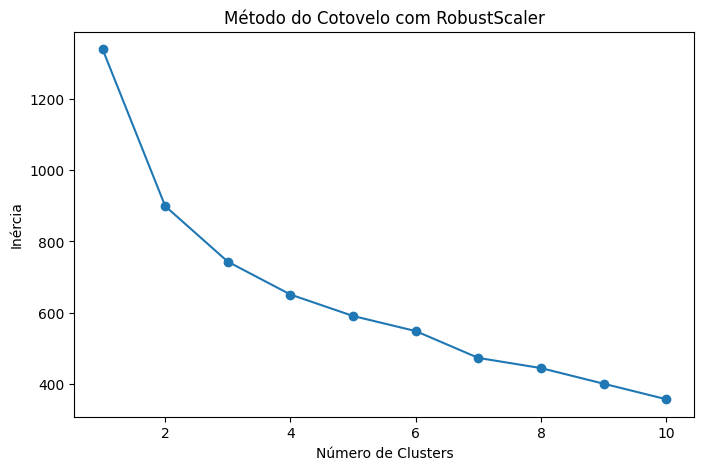

In [97]:
df_kmeans_1 = pokemon_df.copy()
columns_1 = ["offensive_power", "defensive_power", "bulk", "speed_score"]
df_kmeans_1, df_scaled_1 = definir_clusters_cotovelo(df_kmeans_1, columns_1)

In [98]:
import pickle

def run_kmeans(df_kmeans, df_scaled, n_clusters=3, percentile_threshold=95):
    n_clusters = n_clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(df_scaled)

    centroids = kmeans.cluster_centers_
    df_kmeans['cluster'] = clusters

    distances = np.linalg.norm(df_scaled - centroids[clusters], axis=1)
    threshold_distance = np.percentile(distances, percentile_threshold)

    df_kmeans['distance'] = distances
    df_kmeans['outlier'] = df_kmeans['distance'] > threshold_distance

    with open('kmeans_pokemon.pkl', 'wb') as f:
        pickle.dump(kmeans, f)

    return df_kmeans, centroids

In [99]:
outliers_df_1, centroids_1 = run_kmeans(df_kmeans_1, df_scaled_1, n_clusters=7)

In [100]:
plot_distribution(df_kmeans_1, "name", "offensive_power", "defensive_power", "bulk", color="cluster")

In [101]:
plot_distribution(df_kmeans_1, "name", "offensive_power", "defensive_power", "speed_score", color="cluster")

In [102]:
plot_distribution(df_kmeans_1[df_kmeans_1['cluster'] == 0], "name", "offensive_power", "defensive_power", "bulk", color="cluster")

In [103]:
plot_distribution(df_kmeans_1[df_kmeans_1['cluster'] == 1], "name", "offensive_power", "defensive_power", "bulk", color="cluster")

In [ ]:
def resumo_clusters(df, col_cluster, colunas):
    media = df.groupby(col_cluster)[colunas].mean()
    media.columns = [f"{col}_media" for col in media.columns]

    mediana = df.groupby(col_cluster)[colunas].median()
    mediana.columns = [f"{col}_mediana" for col in mediana.columns]

    resumo = pd.concat([media, mediana], axis=1).reset_index()

    return resumo

In [ ]:
resultado = resumo_clusters(df_kmeans_1, 'cluster', columns_1)

In [106]:
display(resultado)

,cluster,offensive_power_media,defensive_power_media,bulk_media,speed_score_media,offensive_power_mediana,defensive_power_mediana,bulk_mediana,speed_score_mediana
0,0,127.937500,120.343750,180.562500,74.812500,135.0,120.0,190.0,75.0
1,1,164.647059,208.735294,295.397059,51.882353,170.0,204.0,288.5,54.5
2,2,163.770492,173.508197,251.737705,89.754098,165.0,172.0,248.0,90.0
3,3,205.428571,152.365079,236.174603,68.857143,200.0,152.0,238.0,68.0
4,4,170.136364,130.954545,203.409091,107.969697,170.0,130.0,203.0,106.0
5,5,143.068182,158.931818,249.545455,50.931818,145.0,160.0,250.0,50.0
6,6,20.000000,460.000000,480.000000,5.000000,20.0,460.0,480.0,5.0


In [ ]:


def plot_clusters_heatmap(df, col_cluster, colunas, tipo='media'):

    if tipo == 'media':
        dados = df.groupby(col_cluster)[colunas].mean()
        titulo = 'Média por Cluster'
    else:
        dados = df.groupby(col_cluster)[colunas].median()
        titulo = 'Mediana por Cluster'

    plt.figure(figsize=(10, 6))
    sns.heatmap(dados, annot=True, fmt=".2f")
    plt.title(titulo)
    plt.ylabel('Cluster')
    plt.xlabel('Variáveis')
    plt.show()

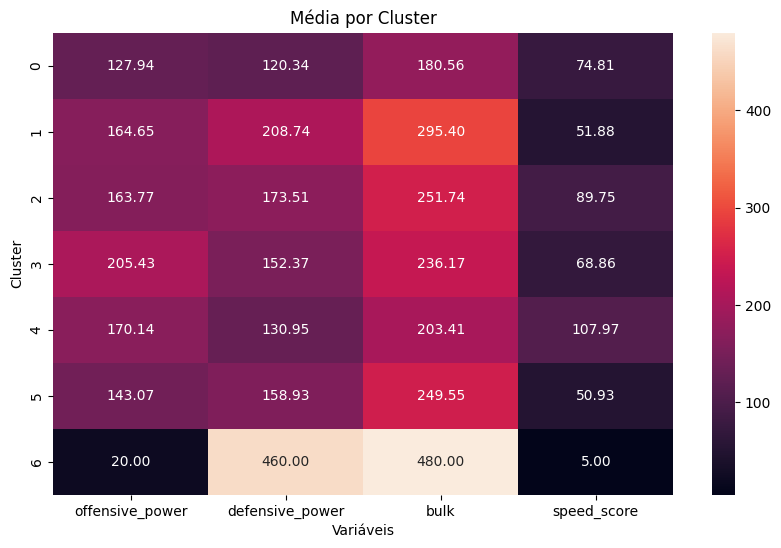

In [112]:
plot_clusters_heatmap(df_kmeans_1, 'cluster', columns_1, tipo='media')